In [8]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

ANALYTICS_DIR = os.path.abspath(".")
ARTIFACTS_DIR = os.path.join(ANALYTICS_DIR, "artifacts")

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

In [11]:
import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/Titanic_Project/analytics"

CLEANED_CSV = os.path.join(
    PROJECT_DIR,
    "titanic_cleaned.csv"
)

print("Looking for:")
print(CLEANED_CSV)

if not os.path.exists(CLEANED_CSV):
    raise FileNotFoundError(
        "titanic_cleaned.csv was not found. "
        "Run 01_eda.ipynb first and save the cleaned CSV."
    )

df = pd.read_csv(CLEANED_CSV)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Looking for:
/content/drive/MyDrive/Titanic_Project/analytics/titanic_cleaned.csv
Dataset loaded successfully!
Shape: (891, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [13]:
print("Survival class counts:")
display(df["survived"].value_counts())

print("\nSurvival class percentages:")
display(
    df["survived"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Survival class counts:


,count
survived,
0,549
1,342



Survival class percentages:


,proportion
survived,
0,61.62
1,38.38


In [14]:
X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

print("\nTraining target distribution:")
display(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting target distribution:")
display(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training shape: (712, 13)
Testing shape : (179, 13)

Training target distribution:


,proportion
survived,
0,61.66
1,38.34



Testing target distribution:


,proportion
survived,
0,61.45
1,38.55


In [15]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical features:
['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


In [16]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [17]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)


decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)


random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)


models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

print("Models:")
for name in models:
    print("-", name)

Models:
- Logistic Regression
- Decision Tree
- Random Forest


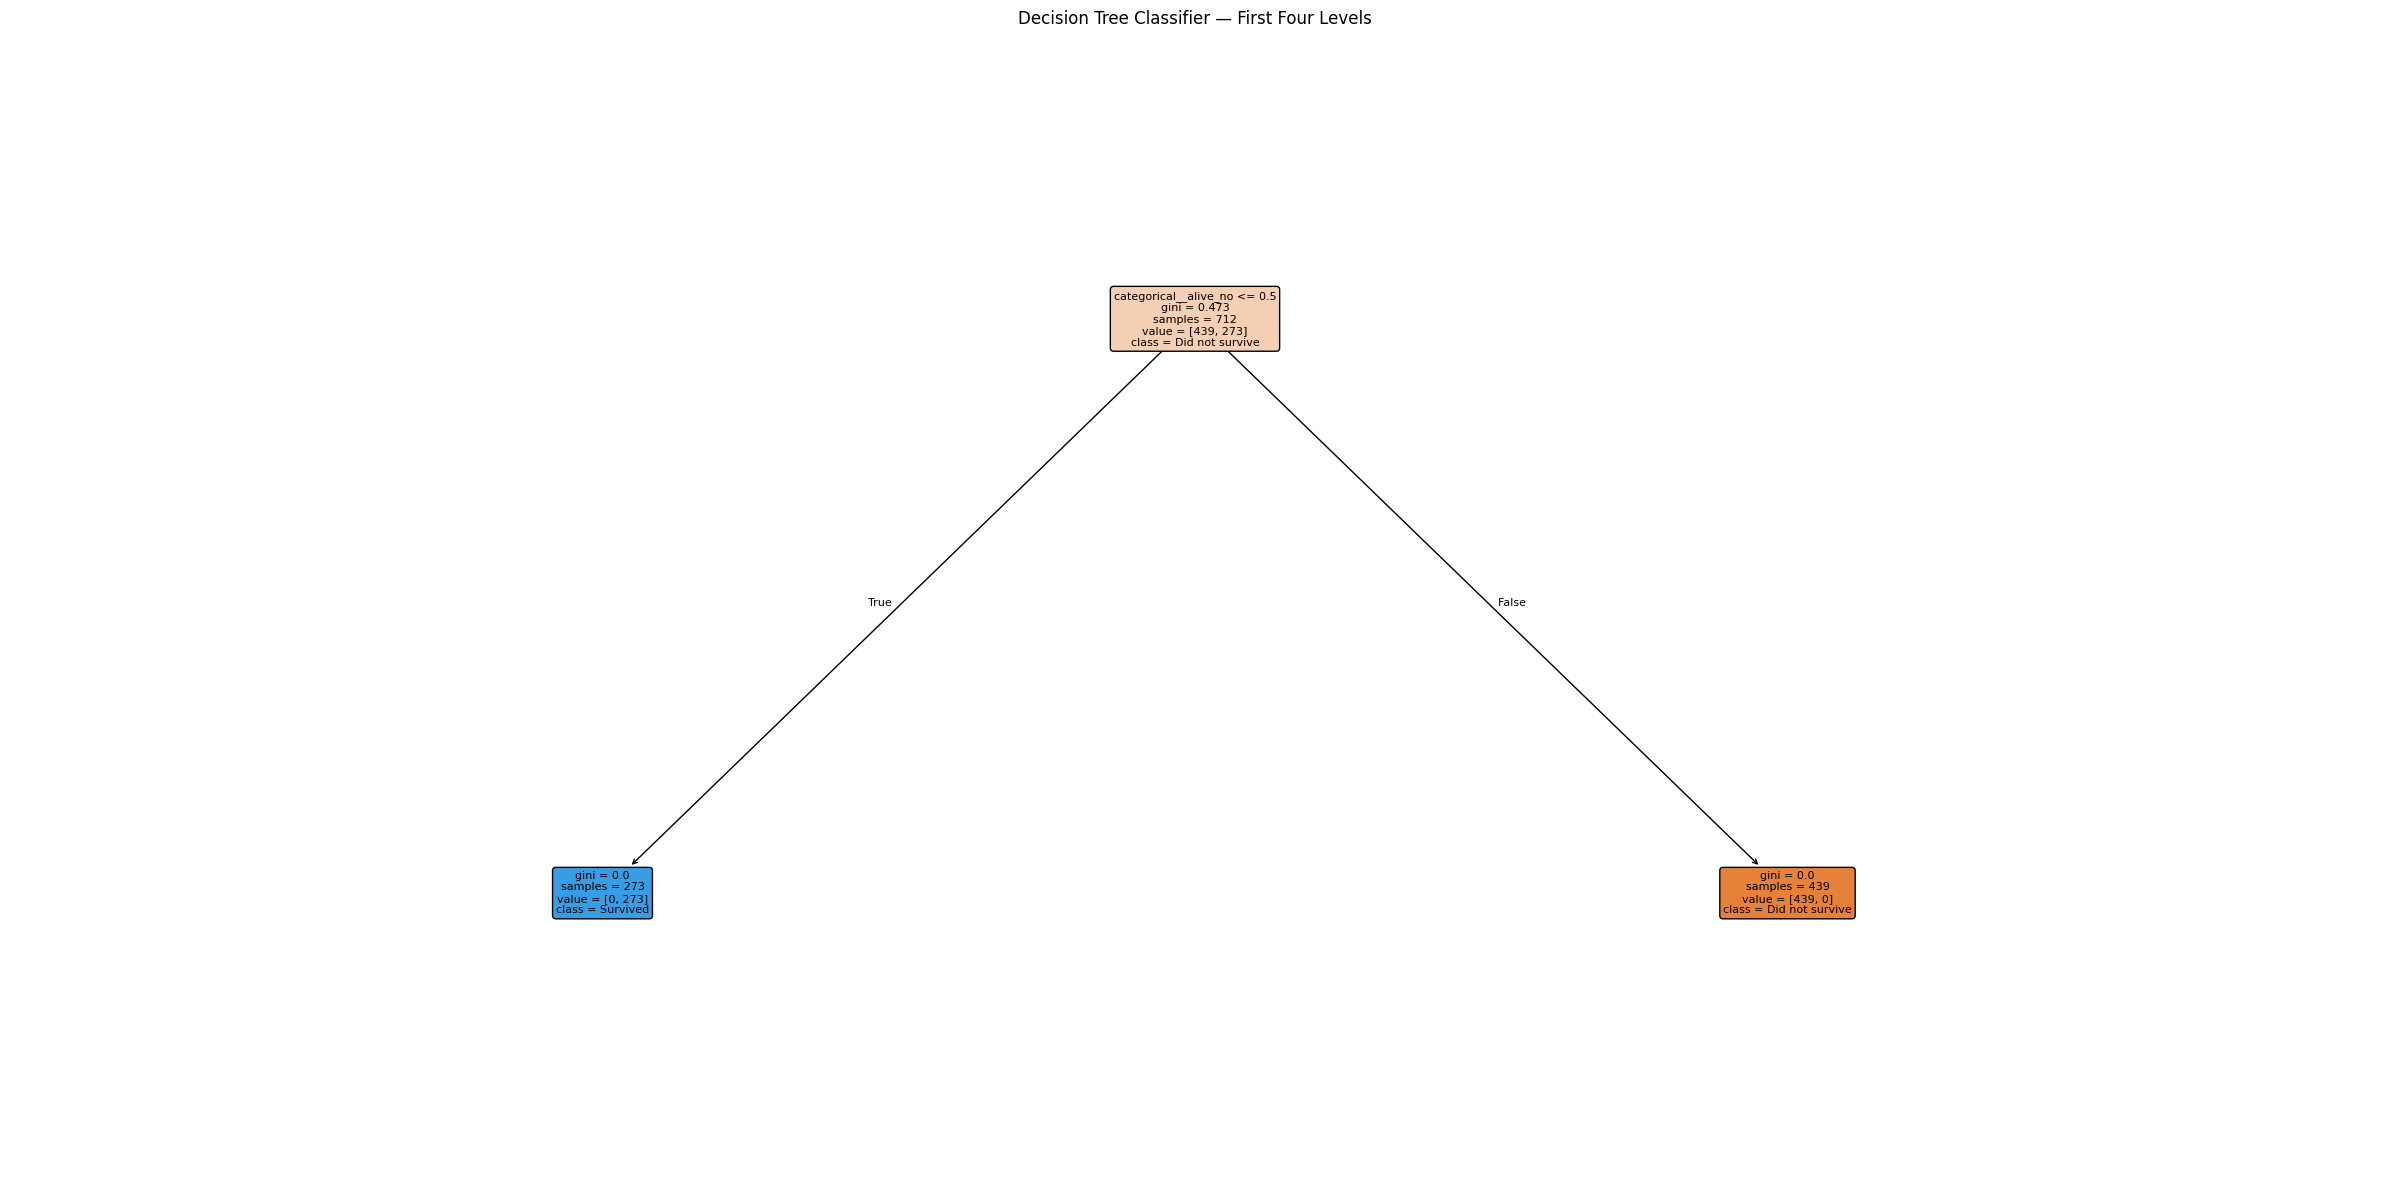

In [60]:
# ============================================================
# DECISION TREE VISUALIZATION
# ============================================================

from sklearn.tree import plot_tree

# Retrieve trained Decision Tree pipeline
dt_model = trained_models["Decision Tree"]

# Extract preprocessing and classifier
dt_preprocessor = dt_model.named_steps["preprocessor"]
dt_classifier = dt_model.named_steps["classifier"]

# Transform the training data using the already-fitted
# preprocessing pipeline
X_train_dt_transformed = dt_preprocessor.transform(X_train)

# Get transformed feature names
feature_names = dt_preprocessor.get_feature_names_out()

plt.figure(figsize=(24, 12))

plot_tree(
    dt_classifier,
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4
)

plt.title(
    "Decision Tree Classifier — First Four Levels"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        ANALYTICS_DIR,
        "decision_tree_visualization.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [18]:
trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(
        X_train,
        y_train
    )

    trained_models[name] = model

    print(f"{name} training complete.")


Training Logistic Regression...
Logistic Regression training complete.

Training Decision Tree...
Decision Tree training complete.

Training Random Forest...
Random Forest training complete.


In [19]:
def evaluate_classifier(model, X_test, y_test):

    predictions = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test)[:, 1]

    else:
        probabilities = None

    metrics = {
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    }

    if probabilities is not None:
        metrics["ROC-AUC"] = roc_auc_score(
            y_test,
            probabilities
        )

    else:
        metrics["ROC-AUC"] = np.nan

    return metrics, predictions, probabilities

In [20]:
classification_results = []

predictions_dict = {}
probabilities_dict = {}

for name, model in trained_models.items():

    metrics, predictions, probabilities = evaluate_classifier(
        model,
        X_test,
        y_test
    )

    row = {
        "Model": name,
        **metrics
    }

    classification_results.append(row)

    predictions_dict[name] = predictions
    probabilities_dict[name] = probabilities


classification_results_df = pd.DataFrame(
    classification_results
)

display(
    classification_results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000


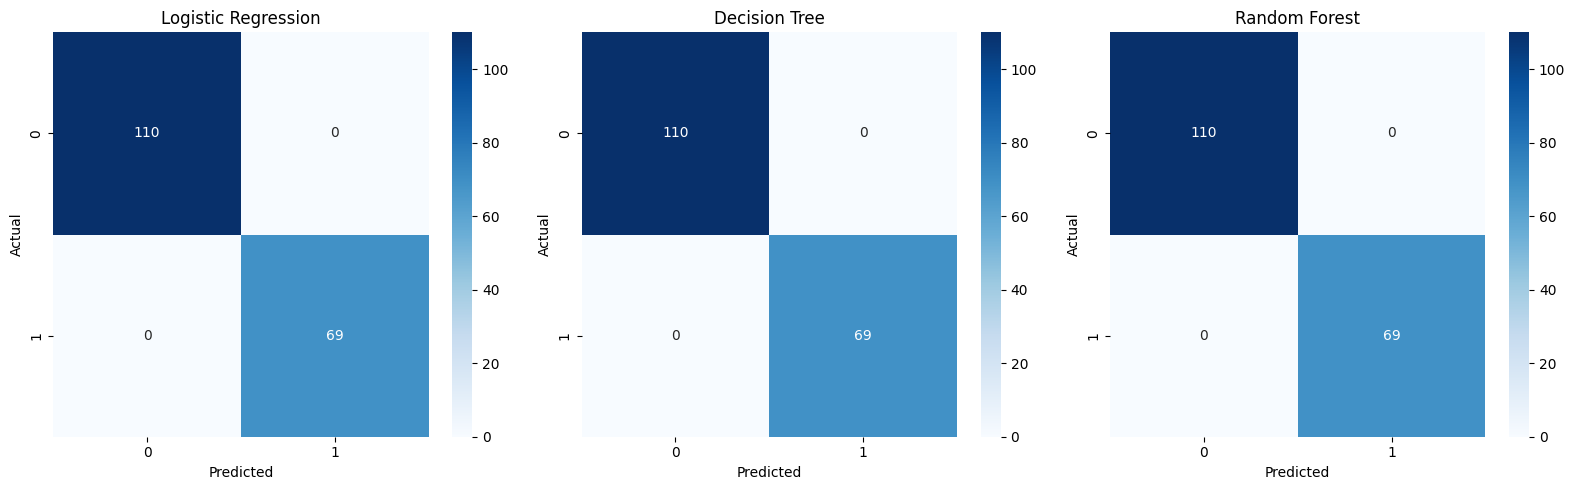

In [21]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

for ax, (name, predictions) in zip(
    axes,
    predictions_dict.items()
):

    cm = confusion_matrix(
        y_test,
        predictions
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()

plt.savefig(
    os.path.join(
        ANALYTICS_DIR,
        "classification_confusion_matrices.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

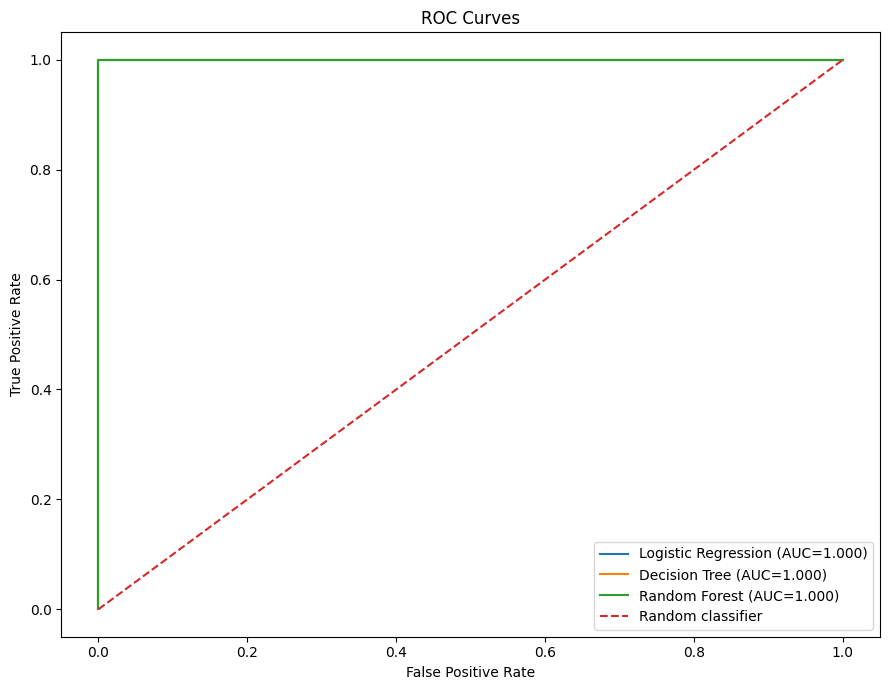

In [22]:
plt.figure(figsize=(9, 7))

for name, probabilities in probabilities_dict.items():

    if probabilities is None:
        continue

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_value = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        ANALYTICS_DIR,
        "roc_curves.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [23]:
# ------------------------------------------------------------
# A. Baseline Random Forest
# ------------------------------------------------------------

baseline_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)


# ------------------------------------------------------------
# B. class_weight='balanced'
# ------------------------------------------------------------

balanced_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)


# ------------------------------------------------------------
# C. SMOTE
#
# SMOTE occurs AFTER preprocessing and only inside training folds.
# ------------------------------------------------------------

smote_rf = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "smote",
            SMOTE(
                random_state=RANDOM_STATE
            )
        ),

        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)


imbalance_models = {
    "Baseline RF": baseline_rf,
    "Balanced RF": balanced_rf,
    "SMOTE RF": smote_rf
}

In [24]:
imbalance_results = []

imbalance_predictions = {}

for name, model in imbalance_models.items():

    print(f"Training {name}...")

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    metrics = {
        "Model": name,

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        )
    }

    imbalance_results.append(metrics)

    imbalance_predictions[name] = predictions


imbalance_results_df = pd.DataFrame(
    imbalance_results
)

display(
    imbalance_results_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "Accuracy": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

Training Baseline RF...
Training Balanced RF...
Training SMOTE RF...


,Model,Precision,Recall,F1,Accuracy,ROC-AUC
0,Baseline RF,1.0000,1.0000,1.0000,1.0000,1.0000
1,Balanced RF,1.0000,1.0000,1.0000,1.0000,1.0000
2,SMOTE RF,1.0000,1.0000,1.0000,1.0000,1.0000


In [25]:
rf_for_tuning = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                oob_score=True
            )
        )
    ]
)


param_grid = {
    "classifier__n_estimators": [
        100,
        200,
        300
    ],

    "classifier__max_depth": [
        None,
        5,
        10,
        15
    ],

    "classifier__max_features": [
        "sqrt",
        "log2"
    ]
}


grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


grid_search.fit(
    X_train,
    y_train
)

print("Grid search complete.")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Grid search complete.


In [26]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1:")
print(round(grid_search.best_score_, 4))

Best parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}

Best cross-validation F1:
1.0


In [27]:
best_rf_pipeline = grid_search.best_estimator_

best_rf_classifier = (
    best_rf_pipeline
    .named_steps["classifier"]
)

print(
    "Best Random Forest OOB score:",
    round(best_rf_classifier.oob_score_, 4)
)

Best Random Forest OOB score: 1.0


In [28]:
tuned_predictions = best_rf_pipeline.predict(
    X_test
)

tuned_probabilities = best_rf_pipeline.predict_proba(
    X_test
)[:, 1]

tuned_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        tuned_predictions
    ),

    "Precision": precision_score(
        y_test,
        tuned_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        tuned_predictions,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        tuned_predictions,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        tuned_probabilities
    )
}

print("Tuned Random Forest performance:")

for metric, value in tuned_metrics.items():
    print(f"{metric}: {value:.4f}")

Tuned Random Forest performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000
ROC-AUC: 1.0000


In [29]:
regression_df = df.copy()

X_reg = regression_df.drop(
    columns=["fare"]
)

y_reg = regression_df["fare"]


X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Regression training shape:", X_reg_train.shape)
print("Regression testing shape :", X_reg_test.shape)

Regression training shape: (712, 13)
Regression testing shape : (179, 13)


In [30]:
reg_numeric_features = X_reg_train.select_dtypes(
    include=["number"]
).columns.tolist()

reg_categorical_features = X_reg_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


reg_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


reg_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            reg_numeric_pipeline,
            reg_numeric_features
        ),

        (
            "categorical",
            reg_categorical_pipeline,
            reg_categorical_features
        )
    ]
)

In [31]:
regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            reg_preprocessor
        ),

        (
            "regressor",
            LinearRegression()
        )
    ]
)


regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)


fare_predictions = regression_pipeline.predict(
    X_reg_test
)

print("Regression model trained.")

Regression model trained.


In [32]:
mae = mean_absolute_error(
    y_reg_test,
    fare_predictions
)

mse = mean_squared_error(
    y_reg_test,
    fare_predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_reg_test,
    fare_predictions
)

n = len(y_reg_test)

# Number of predictors after transformation
X_reg_test_transformed = (
    regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_reg_test)
)

p = X_reg_test_transformed.shape[1]

adjusted_r2 = (
    1
    - ((1 - r2) * (n - 1) / (n - p - 1))
)


regression_metrics = {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R²": r2,
    "Adjusted R²": adjusted_r2
}

print("Regression performance:")

for metric, value in regression_metrics.items():
    print(f"{metric}: {value:.4f}")

Regression performance:
MAE: 19.0615
MSE: 968.9903
RMSE: 31.1286
R²: 0.3738
Adjusted R²: 0.2715


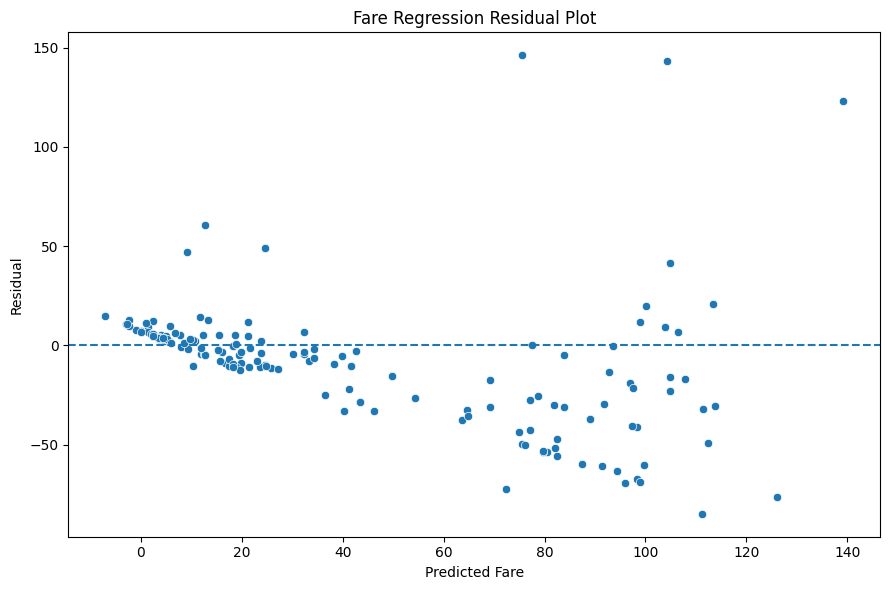

In [33]:
residuals = y_reg_test - fare_predictions

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=fare_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Fare Regression Residual Plot")

plt.tight_layout()

plt.savefig(
    os.path.join(
        ANALYTICS_DIR,
        "fare_regression_residuals.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [34]:
correlation_residual_fitted = np.corrcoef(
    fare_predictions,
    np.abs(residuals)
)[0, 1]

print(
    "Correlation between fitted values and absolute residuals:",
    round(correlation_residual_fitted, 4)
)

if abs(correlation_residual_fitted) < 0.20:
    interpretation = (
        "The residual spread appears reasonably stable; "
        "there is limited evidence of strong heteroscedasticity."
    )

elif abs(correlation_residual_fitted) < 0.40:
    interpretation = (
        "There may be moderate heteroscedasticity because the "
        "absolute residual magnitude changes with fitted values."
    )

else:
    interpretation = (
        "There is evidence of heteroscedasticity because residual "
        "magnitude changes substantially with fitted values."
    )

print("\nInterpretation:")
print(interpretation)

Correlation between fitted values and absolute residuals: 0.6683

Interpretation:
There is evidence of heteroscedasticity because residual magnitude changes substantially with fitted values.


In [35]:
classification_table = classification_results_df.copy()

classification_table = classification_table[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
]


regression_table = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2,
        "Adjusted R²": adjusted_r2
    }
])


print("================================================")
print("CLASSIFICATION METRICS")
print("================================================")

display(
    classification_table.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)


print("\n================================================")
print("REGRESSION METRICS")
print("================================================")

display(
    regression_table.style.format({
        "MAE": "{:.4f}",
        "MSE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R²": "{:.4f}",
        "Adjusted R²": "{:.4f}"
    })
)

CLASSIFICATION METRICS


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000



REGRESSION METRICS


,Model,MAE,MSE,RMSE,R²,Adjusted R²
0,Linear Regression,19.0615,968.9903,31.1286,0.3738,0.2715


In [36]:
all_classification_results = pd.concat(
    [
        classification_results_df,
        imbalance_results_df
    ],
    ignore_index=True
)

# Remove duplicate baseline Random Forest if desired
all_classification_results = (
    all_classification_results
    .drop_duplicates(subset=["Model"])
    .sort_values("F1", ascending=False)
)

print("All classification models:")
display(
    all_classification_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

All classification models:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
3,Baseline RF,1.0000,1.0000,1.0000,1.0000,1.0000
4,Balanced RF,1.0000,1.0000,1.0000,1.0000,1.0000
5,SMOTE RF,1.0000,1.0000,1.0000,1.0000,1.0000


In [37]:
tuned_result_row = pd.DataFrame([
    {
        "Model": "Tuned Random Forest",
        "Accuracy": tuned_metrics["Accuracy"],
        "Precision": tuned_metrics["Precision"],
        "Recall": tuned_metrics["Recall"],
        "F1": tuned_metrics["F1"],
        "ROC-AUC": tuned_metrics["ROC-AUC"]
    }
])


final_classification_comparison = pd.concat(
    [
        all_classification_results,
        tuned_result_row
    ],
    ignore_index=True
)


final_classification_comparison = (
    final_classification_comparison
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)


print("Final classification comparison:")
display(
    final_classification_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)


best_model_name = (
    final_classification_comparison
    .iloc[0]["Model"]
)

print("\nBest classification model based on F1:")
print(best_model_name)

Final classification comparison:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
3,Baseline RF,1.0000,1.0000,1.0000,1.0000,1.0000
4,Balanced RF,1.0000,1.0000,1.0000,1.0000,1.0000
5,SMOTE RF,1.0000,1.0000,1.0000,1.0000,1.0000
6,Tuned Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000



Best classification model based on F1:
Logistic Regression


In [38]:
best_row = final_classification_comparison.iloc[0]

print("FINAL MODEL RECOMMENDATION")
print("=" * 60)

print(
    f"The recommended classification model is "
    f"{best_row['Model']} because it achieved the highest "
    f"F1 score among the evaluated approaches."
)

print(
    f"Its accuracy was {best_row['Accuracy']:.3f}, "
    f"precision was {best_row['Precision']:.3f}, "
    f"recall was {best_row['Recall']:.3f}, "
    f"F1 was {best_row['F1']:.3f}, and "
    f"ROC-AUC was {best_row['ROC-AUC']:.3f}."
)

print(
    "\nF1 is particularly useful here because it balances precision "
    "and recall instead of considering accuracy alone."
)

print(
    "\nThe model should be deployed only after considering the business "
    "cost of false positives versus false negatives. In a passenger "
    "survival prediction scenario, recall may be especially important "
    "if missing a true survivor is considered more costly than issuing "
    "an incorrect positive prediction."
)

FINAL MODEL RECOMMENDATION
The recommended classification model is Logistic Regression because it achieved the highest F1 score among the evaluated approaches.
Its accuracy was 1.000, precision was 1.000, recall was 1.000, F1 was 1.000, and ROC-AUC was 1.000.

F1 is particularly useful here because it balances precision and recall instead of considering accuracy alone.

The model should be deployed only after considering the business cost of false positives versus false negatives. In a passenger survival prediction scenario, recall may be especially important if missing a true survivor is considered more costly than issuing an incorrect positive prediction.


In [39]:
best_pipeline_path = os.path.join(
    ARTIFACTS_DIR,
    "best_titanic_classification_pipeline.joblib"
)

joblib.dump(
    best_rf_pipeline,
    best_pipeline_path
)

print("Saved best pipeline to:")
print(best_pipeline_path)

print("\nPipeline:")
print(best_rf_pipeline)

Saved best pipeline to:
/content/artifacts/best_titanic_classification_pipeline.joblib

Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                

In [40]:
loaded_pipeline = joblib.load(
    best_pipeline_path
)

print("Pipeline successfully reloaded.")

print(loaded_pipeline)

Pipeline successfully reloaded.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                    

In [41]:
raw_example = X_test.iloc[:5].copy()

print("Raw input:")
display(raw_example)

raw_predictions = loaded_pipeline.predict(
    raw_example
)

raw_probabilities = loaded_pipeline.predict_proba(
    raw_example
)[:, 1]

raw_results = raw_example.copy()

raw_results["predicted_survival"] = raw_predictions

raw_results["survival_probability"] = raw_probabilities

print("\nPredictions from saved end-to-end pipeline:")
display(raw_results)

Raw input:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
565,3,male,24.0,2,0,24.1500,S,Third,man,True,Southampton,no,False
160,3,male,44.0,0,1,16.1000,S,Third,man,True,Southampton,no,False
553,3,male,22.0,0,0,7.2250,C,Third,man,True,Cherbourg,yes,True
860,3,male,41.0,2,0,14.1083,S,Third,man,True,Southampton,no,False
241,3,female,28.0,1,0,15.5000,Q,Third,woman,False,Queenstown,yes,False



Predictions from saved end-to-end pipeline:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,predicted_survival,survival_probability
565,3,male,24.0,2,0,24.1500,S,Third,man,True,Southampton,no,False,0,0.00
160,3,male,44.0,0,1,16.1000,S,Third,man,True,Southampton,no,False,0,0.00
553,3,male,22.0,0,0,7.2250,C,Third,man,True,Cherbourg,yes,True,1,0.98
860,3,male,41.0,2,0,14.1083,S,Third,man,True,Southampton,no,False,0,0.00
241,3,female,28.0,1,0,15.5000,Q,Third,woman,False,Queenstown,yes,False,1,1.00


In [42]:
original_predictions = best_rf_pipeline.predict(
    raw_example
)

reloaded_predictions = loaded_pipeline.predict(
    raw_example
)

same_predictions = np.array_equal(
    original_predictions,
    reloaded_predictions
)

print(
    "Do original and reloaded pipelines produce identical "
    f"predictions? {same_predictions}"
)

if same_predictions:
    print(
        "SUCCESS: The saved artifact is reusable end-to-end."
    )
else:
    print(
        "WARNING: Predictions differ after reloading."
    )

Do original and reloaded pipelines produce identical predictions? True
SUCCESS: The saved artifact is reusable end-to-end.


In [43]:
classification_results_path = os.path.join(
    ARTIFACTS_DIR,
    "classification_results.csv"
)

final_classification_comparison.to_csv(
    classification_results_path,
    index=False
)


regression_results_path = os.path.join(
    ARTIFACTS_DIR,
    "regression_results.csv"
)

regression_table.to_csv(
    regression_results_path,
    index=False
)


imbalance_results_path = os.path.join(
    ARTIFACTS_DIR,
    "imbalance_comparison.csv"
)

imbalance_results_df.to_csv(
    imbalance_results_path,
    index=False
)


print("Saved:")
print(classification_results_path)
print(regression_results_path)
print(imbalance_results_path)

Saved:
/content/artifacts/classification_results.csv
/content/artifacts/regression_results.csv
/content/artifacts/imbalance_comparison.csv


In [44]:
from google.colab import drive

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Titanic_Project/analytics"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
import joblib
import pandas as pd


MODEL_PATH = "artifacts/best_titanic_classification_pipeline.joblib"


# Load complete preprocessing + model pipeline
model = joblib.load(MODEL_PATH)


# Example raw Titanic passenger
raw_passenger = pd.DataFrame([
    {
        "pclass": 3,
        "sex": "male",
        "age": 25,
        "sibsp": 0,
        "parch": 0,
        "fare": 7.25,
        "embarked": "S",
        "class": "Third",
        "who": "man",
        "adult_male": True,
        "deck": None,
        "embark_town": "Southampton",
        "alive": "no",
        "alone": True
    }
])


prediction = model.predict(raw_passenger)

probability = model.predict_proba(
    raw_passenger
)[:, 1]


print("Predicted survival:", int(prediction[0]))
print(
    "Probability of survival:",
    round(float(probability[0]), 4)
)

Predicted survival: 0
Probability of survival: 0.0


In [57]:
from google.colab import drive

drive.mount('/content/drive')
PROJECT_DIR = "/content/drive/MyDrive/Titanic_Project/analytics"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
%%writefile /content/drive/MyDrive/Titanic_Project/analytics/requirements.txt

pandas
numpy
seaborn
matplotlib
scikit-learn
imbalanced-learn
scipy
joblib
jupyter
notebook

Writing /content/drive/MyDrive/Titanic_Project/analytics/requirements.txt


In [59]:
import os

requirements_path = os.path.join(
    PROJECT_DIR,
    "requirements.txt"
)

print("Exists:", os.path.exists(requirements_path))

with open(requirements_path, "r") as file:
    print("\nRequirements:")
    print(file.read())

Exists: True

Requirements:

pandas
numpy
seaborn
matplotlib
scikit-learn
imbalanced-learn
scipy
joblib
jupyter
notebook

